# Smart Home Energy Consumption Forecasting
**End-to-end ML pipeline: Preprocessing → EDA → Feature Engineering → Model Training → Evaluation**

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Step 1: Data Preprocessing

In [3]:
df = pd.read_csv("smart_home_energy_usage_dataset.csv")

# Strip whitespace from column names to avoid hidden KeyErrors
df.columns = df.columns.str.strip()

# Convert BEFORE sorting
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values(["Home_ID", "DateTime"]).reset_index(drop=True)

# This dataset has no missing values so no imputation needed.
# If you ever add missing data: df.ffill() then df.bfill() is safe in pandas 3.x
# DO NOT use groupby().apply() for imputation in pandas 3.x — it drops the group column.

print(f"Dataset: {df.shape[0]:,} rows | {df['Home_ID'].nunique()} homes")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Date range: {df['DateTime'].min()} -> {df['DateTime'].max()}")
df.head()

Dataset: 500 rows | 100 homes
Missing values: 0
Date range: 2025-01-01 00:00:00 -> 2025-03-01 00:00:00


,Home_ID,DateTime,Temperature_C,Humidity_%,Light_Lux,Appliance_Usage_kWh,HVAC_Usage_kWh,Water_Heater_kWh,Total_Energy_kWh,Motion_Sensor,Room
0,H001,2025-01-20 15:03:14.789579158,16.4,42.4,508.0,3.33,4.37,0.52,8.22,Inactive,Bedroom
1,H001,2025-02-03 19:34:30.541082164,29.2,79.5,529.0,4.98,0.64,5.14,10.76,Inactive,Living Room
2,H002,2025-01-22 18:07:56.152304609,33.6,61.6,894.0,0.84,8.98,2.27,12.09,Inactive,Bedroom
3,H002,2025-02-26 20:55:18.637274549,21.7,62.3,988.0,0.99,5.89,1.04,7.92,Active,Bathroom
4,H003,2025-01-29 23:13:49.659318637,29.8,72.2,845.0,1.10,1.44,5.80,8.34,Active,Living Room


## Step 2: Exploratory Data Analysis (EDA)

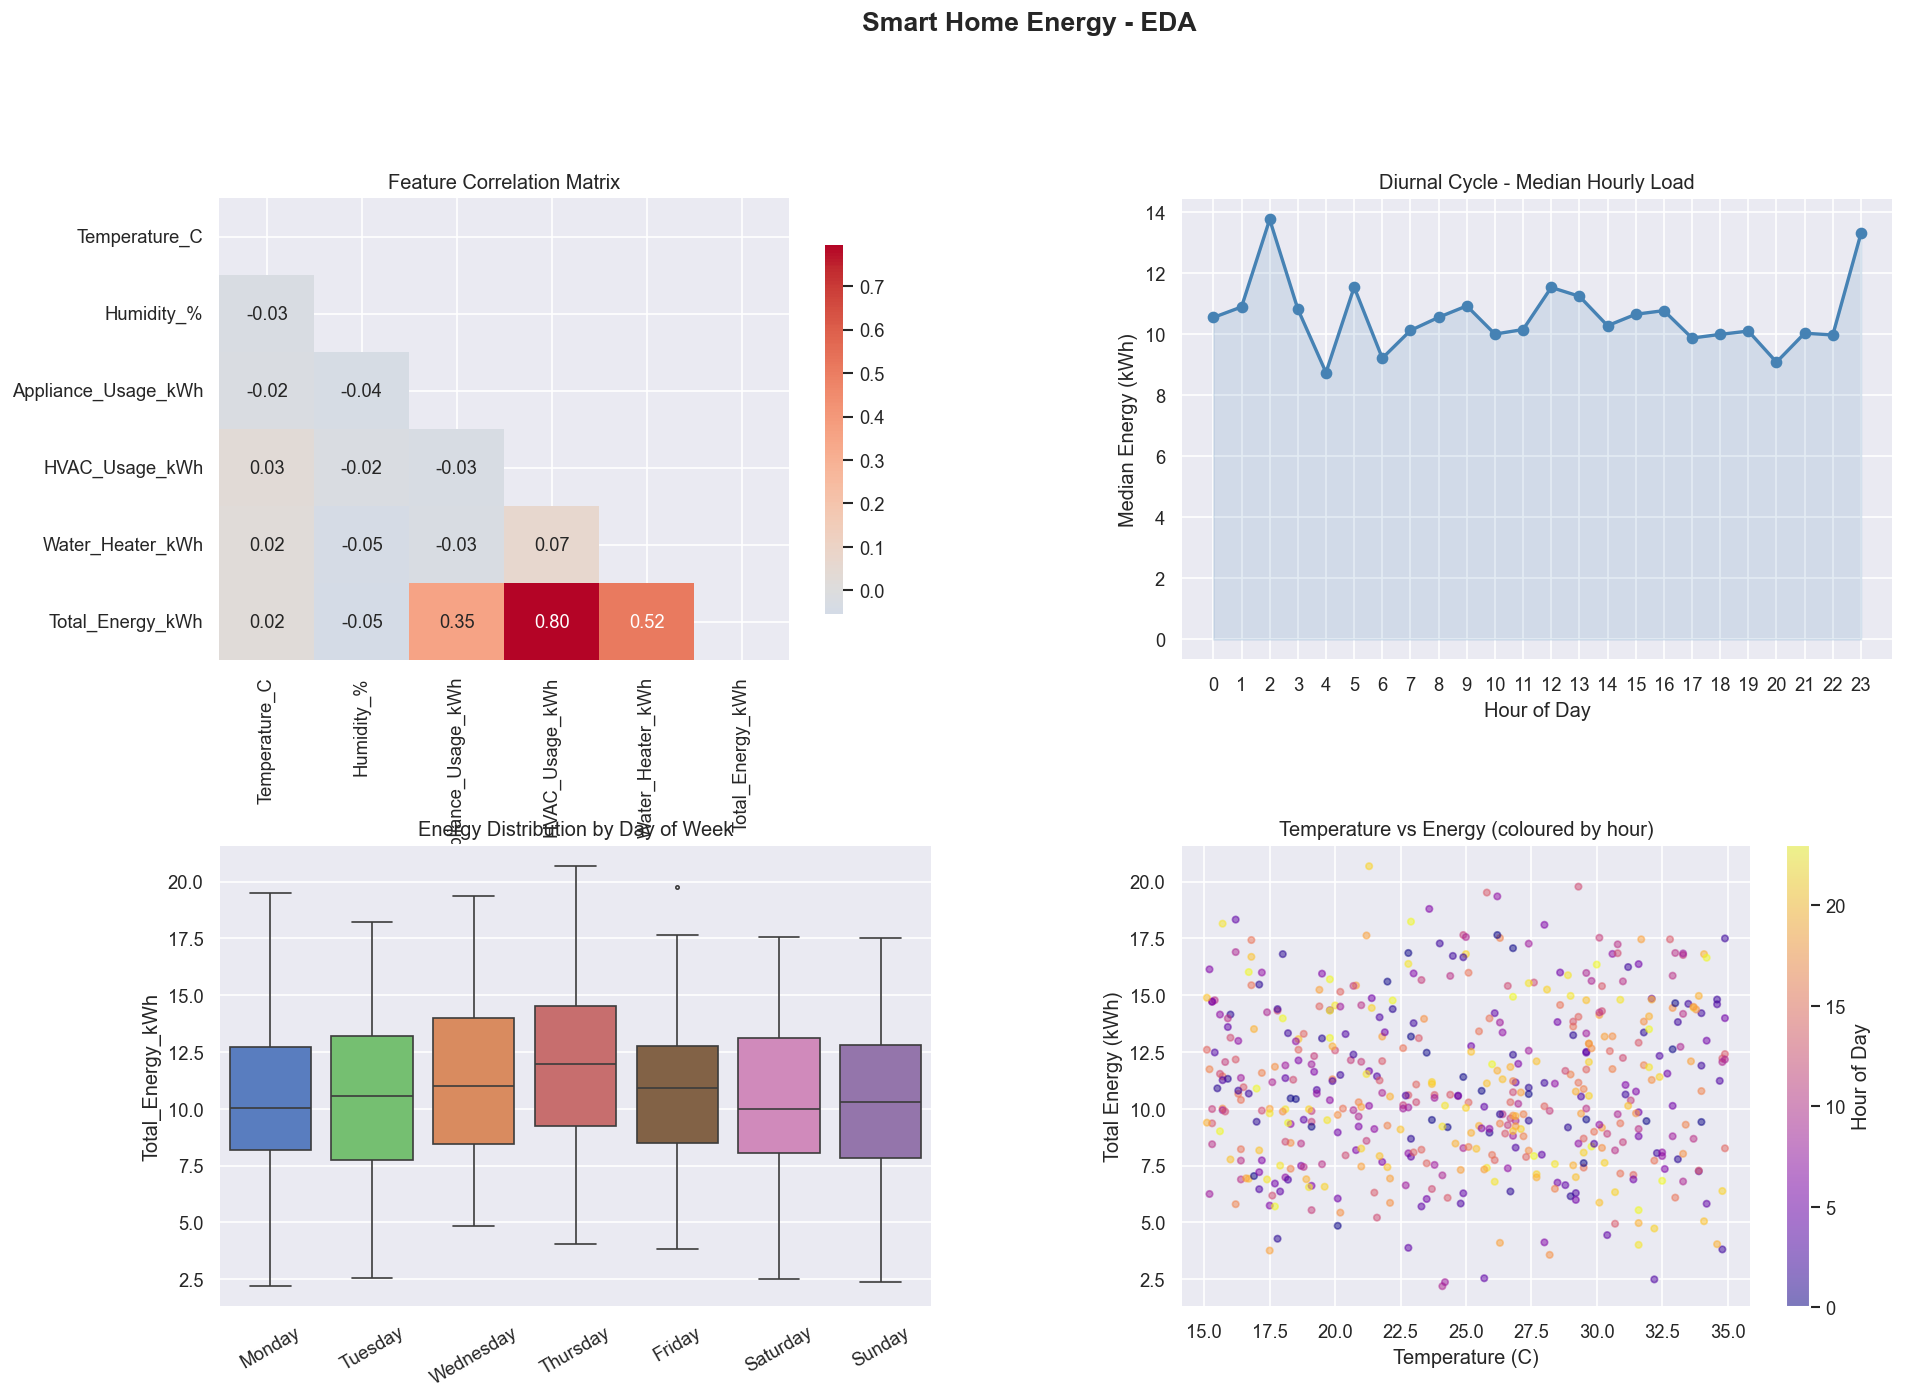

In [4]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Smart Home Energy - EDA", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# 2a. Correlation heatmap
ax1 = fig.add_subplot(gs[0, 0])
numeric_cols = ["Temperature_C", "Humidity_%", "Appliance_Usage_kWh",
                "HVAC_Usage_kWh", "Water_Heater_kWh", "Total_Energy_kWh"]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax1, cbar_kws={"shrink": 0.8})
ax1.set_title("Feature Correlation Matrix")

# 2b. Diurnal cycle - median energy by hour
ax2 = fig.add_subplot(gs[0, 1])
hourly = df.groupby(df["DateTime"].dt.hour)["Total_Energy_kWh"].median()
ax2.plot(hourly.index, hourly.values, marker="o", linewidth=2, color="steelblue")
ax2.fill_between(hourly.index, hourly.values, alpha=0.15, color="steelblue")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Median Energy (kWh)")
ax2.set_title("Diurnal Cycle - Median Hourly Load")
ax2.set_xticks(sorted(df["DateTime"].dt.hour.unique()))

# 2c. Energy distribution by day of week
ax3 = fig.add_subplot(gs[1, 0])
df["DayName"] = df["DateTime"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sns.boxplot(data=df, x="DayName", y="Total_Energy_kWh", order=day_order,
            hue="DayName", legend=False, palette="muted", ax=ax3, fliersize=2)
ax3.set_title("Energy Distribution by Day of Week")
ax3.set_xlabel("")
ax3.tick_params(axis="x", rotation=30)


# 2d. Temperature vs Total Energy scatter
ax4 = fig.add_subplot(gs[1, 1])
sample = df.sample(min(3000, len(df)), random_state=42)
sc = ax4.scatter(sample["Temperature_C"], sample["Total_Energy_kWh"],
                 c=sample["DateTime"].dt.hour, cmap="plasma", alpha=0.5, s=15)
plt.colorbar(sc, ax=ax4, label="Hour of Day")
ax4.set_xlabel("Temperature (C)")
ax4.set_ylabel("Total Energy (kWh)")
ax4.set_title("Temperature vs Energy (coloured by hour)")

plt.savefig("outputs/eda_overview.png", bbox_inches="tight")
plt.show()

## Step 3: Feature Engineering

In [5]:
# --- 1. Basic Time Features ---
df["Hour"]      = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.dayofweek
df["Month"]     = df["DateTime"].dt.month
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

# --- 2. Cyclical Encoding ---
df["Hour_sin"]  = np.sin(2 * np.pi * df["Hour"]  / 24)
df["Hour_cos"]  = np.cos(2 * np.pi * df["Hour"]  / 24)
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# --- 3. Lag Features & Rolling Stats ---
# Removed 24h lag because the dataset sample is too small per home 
for lag in [1, 2, 3]:          
    df[f"Lag_{lag}h"] = df.groupby("Home_ID")["Total_Energy_kWh"].shift(lag)

df["Rolling_Mean_3h"] = df.groupby("Home_ID")["Total_Energy_kWh"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
df["Rolling_Std_3h"] = df.groupby("Home_ID")["Total_Energy_kWh"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).std().fillna(0)
)

# --- 4. Handle NaNs Safely ---
print(f"Rows before dropping NaNs: {len(df):,}")
df = df.dropna().reset_index(drop=True)
print(f"Rows after dropping NaNs: {len(df):,}")

# --- 5. Define Features ---
FEATURES = [
    "Temperature_C", "Humidity_%",
    "Hour_sin", "Hour_cos", "Month_sin", "Month_cos",
    "DayOfWeek", "IsWeekend",
    "Lag_1h", "Lag_2h", "Lag_3h",
    "Rolling_Mean_3h", "Rolling_Std_3h",
]

# --- 6. Chronological Train/Test Split ---
cutoff_date = df["DateTime"].quantile(0.8)
train_mask = df["DateTime"] <= cutoff_date

df_train = df[train_mask]
df_test  = df[~train_mask]

X_train, y_train = df_train[FEATURES], df_train["Total_Energy_kWh"]
X_test, y_test   = df_test[FEATURES], df_test["Total_Energy_kWh"]

# --- 7. Scaling ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train set: {len(X_train):,} samples | Test set: {len(X_test):,} samples")

Rows before dropping NaNs: 500
Rows after dropping NaNs: 222
Train set: 177 samples | Test set: 45 samples


## Step 4: Model Training

In [6]:
results = {}

### Model 1: Linear Regression (Baseline)

In [7]:
# Simple baseline - no hyperparameters to tune.
# Requires scaled input (X_train_sc / X_test_sc) because it is
# sensitive to feature magnitude.

lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
lr_preds = lr_model.predict(X_test_sc)

results["Linear Regression"] = {
    "MAE":         mean_absolute_error(y_test, lr_preds),
    "RMSE":        np.sqrt(mean_squared_error(y_test, lr_preds)),
    "R2":          r2_score(y_test, lr_preds),
    "Predictions": lr_preds,
    "Model":       lr_model,
}

print(f"Linear Regression -> MAE: {results['Linear Regression']['MAE']:.4f} | "
      f"RMSE: {results['Linear Regression']['RMSE']:.4f} | "
      f"R2: {results['Linear Regression']['R2']:.4f}")

Linear Regression -> MAE: 2.8855 | RMSE: 3.6913 | R2: -0.0007


### Model: XGBoost (High-Achiever)

In [8]:
# Gradient boosted trees - does NOT need scaled input.
# n_estimators         : max number of boosting rounds
# learning_rate        : shrinks each tree's contribution -> reduces overfitting
# max_depth            : depth of each tree; deeper = more complex patterns
# subsample            : fraction of rows sampled per tree -> adds randomness
# colsample_bytree     : fraction of features sampled per tree -> adds randomness
# early_stopping_rounds: stops training if validation RMSE does not improve
#                        for 20 consecutive rounds -> prevents overfitting automatically

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric="rmse",
    random_state=42,
    verbosity=0,
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
xgb_preds = xgb_model.predict(X_test)

results["XGBoost"] = {
    "MAE":         mean_absolute_error(y_test, xgb_preds),
    "RMSE":        np.sqrt(mean_squared_error(y_test, xgb_preds)),
    "R2":          r2_score(y_test, xgb_preds),
    "Predictions": xgb_preds,
    "Model":       xgb_model,
}

print(f"XGBoost -> MAE: {results['XGBoost']['MAE']:.4f} | "
      f"RMSE: {results['XGBoost']['RMSE']:.4f} | "
      f"R2: {results['XGBoost']['R2']:.4f}")

XGBoost           -> MAE: 2.8869 | RMSE: 3.6927 | R2: -0.0014


### Model 3: Random Forest (Baseline)

In [11]:
rf_model = RandomForestRegressor(n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

results["Random Forest"] = {
    "MAE": mean_absolute_error(y_test, rf_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_preds)),
    "R2": r2_score(y_test, rf_preds),
    "Predictions": rf_preds,
    "Model": rf_model,
}


print(f"Random Forest -> MAE: {results['Random Forest']['MAE']:.4f} | "
      f"RMSE: {results['Random Forest']['RMSE']:.4f} | "
      f"R2: {results['Random Forest']['R2']:.4f}")


Random Forest -> MAE: 3.0846 | RMSE: 3.8899 | R2: -0.1113


## Step 5: Evaluation & Visualisation

In [12]:
# 5a. Metrics table
metrics_df = (
    pd.DataFrame(results)
    .T[["MAE", "RMSE", "R2"]]
    .round(4)
    .sort_values("RMSE")
)
print("Model Performance Comparison")
metrics_df

Model Performance Comparison


,MAE,RMSE,R2
Linear Regression,2.885462,3.691331,-0.000696
XGBoost,2.886909,3.692708,-0.001443
Random Forest,3.084626,3.889902,-0.111254


Step 6: Optimization